# LSTM Eğitimi

Bu notebook, 20 işlem günlük pencerelerle bir sonraki MSFT kapanış fiyatını tahmin eden LSTM modelini eğitir. Deney yalnızca **train** ve **validation** dönemlerini kullanır. En düşük validation kaybındaki model ağırlıkları değerlendirme için geri yüklenir. Test dönemi saklı tutulur; GRU modeli bu deneye dahil edilmez.

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.optim import Adam

from ms_stock_prediction.models import LSTMModel, count_trainable_parameters
from ms_stock_prediction.preprocessing import (
    PreparationConfig,
    load_close_prices,
    prepare_time_series,
)
from ms_stock_prediction.training import evaluate_loss, train_one_epoch

SEED = 42
EPOCHS = 50
LEARNING_RATE = 0.001
HIDDEN_SIZE = 32
NUM_LAYERS = 2
BATCH_SIZE = 32
DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## Deney düzeni

- Sabit rastgelelik tohumu: `42`
- Model: 2 katmanlı LSTM, 32 gizli birim
- Kayıp fonksiyonu: MSE
- Optimizasyon: Adam, öğrenme oranı `0.001`
- Eğitim süresi: 50 epoch
- Donanım: CPU
- Model seçimi için kullanılan dönem: validation

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
prices = load_close_prices(DATA_PATH)
config = PreparationConfig(lookback=20, batch_size=BATCH_SIZE, shuffle_seed=SEED)
prepared = prepare_time_series(prices, config)

data_summary = pd.DataFrame(
    {
        "Dönem": ["Train", "Validation", "Test (saklı)"],
        "Gözlem": [
            len(prepared.train_prices),
            len(prepared.validation_prices),
            len(prepared.test_prices),
        ],
        "Hedef sayısı": [
            len(prepared.y_train),
            len(prepared.y_validation),
            len(prepared.y_test),
        ],
        "Başlangıç": [
            prepared.train_prices.index.min().date(),
            prepared.validation_prices.index.min().date(),
            prepared.test_prices.index.min().date(),
        ],
        "Bitiş": [
            prepared.train_prices.index.max().date(),
            prepared.validation_prices.index.max().date(),
            prepared.test_prices.index.max().date(),
        ],
    }
)
display(data_summary)

,Dönem,Gözlem,Hedef sayısı,Başlangıç,Bitiş
0,Train,2909,2889,2010-01-04,2021-07-23
1,Validation,623,623,2021-07-26,2024-01-16
2,Test (saklı),624,624,2024-01-17,2026-07-14


## LSTM mimarisi

Model her örnekteki 20 kapanış fiyatını sırayla işler ve son zaman adımındaki temsilden tek bir ölçeklenmiş fiyat üretir.

In [3]:
model = LSTMModel(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=1,
).to(DEVICE)
loss_function = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print(f"Eğitilebilir parametre: {count_trainable_parameters(model):,}")
print(f"Cihaz: {DEVICE}")

LSTMModel(
  (recurrent): LSTM(1, 32, num_layers=2, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)
Eğitilebilir parametre: 12,961
Cihaz: cpu


## Eğitim

Her epoch sonunda train ve validation MSE kayıpları kaydedilir. Validation kaybı yalnızca değerlendirme amacıyla hesaplanır; bu sırada ağırlıklar güncellenmez. En düşük validation kaybındaki ağırlıklar bellekte saklanır ve metrik hesabından önce geri yüklenir.

In [4]:
history = []
best_validation_loss = float("inf")
best_epoch = 0
best_model_state = None
training_started = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model, prepared.train_loader, optimizer, loss_function, DEVICE
    )
    validation_loss = evaluate_loss(
        model, prepared.validation_loader, loss_function, DEVICE
    )
    history.append(
        {
            "Epoch": epoch,
            "Train MSE (scaled)": train_loss,
            "Validation MSE (scaled)": validation_loss,
        }
    )
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train={train_loss:.6f} | validation={validation_loss:.6f}"
    )

training_seconds = time.perf_counter() - training_started
if best_model_state is None:
    raise RuntimeError("Eğitim sırasında geçerli model ağırlığı üretilemedi.")
model.load_state_dict(best_model_state)
history_df = pd.DataFrame(history).set_index("Epoch")
print(f"Eğitim süresi: {training_seconds:.2f} saniye")
print(
    f"Seçilen epoch: {best_epoch} | "
    f"validation={best_validation_loss:.6f}"
)

Epoch 01/50 | train=0.141562 | validation=0.336362


Epoch 02/50 | train=0.001856 | validation=0.073548


Epoch 03/50 | train=0.000709 | validation=0.038006


Epoch 04/50 | train=0.000643 | validation=0.028477


Epoch 05/50 | train=0.000594 | validation=0.024476


...

Epoch 46/50 | train=0.000285 | validation=0.003122


Epoch 47/50 | train=0.000289 | validation=0.002849


Epoch 48/50 | train=0.000252 | validation=0.003231


Epoch 49/50 | train=0.000258 | validation=0.002769


Epoch 50/50 | train=0.000271 | validation=0.005901
Eğitim süresi: 20.07 saniye
Seçilen epoch: 49 | validation=0.002769


,Train MSE (scaled),Validation MSE (scaled)
Epoch,,
1,0.1416,0.3364
2,0.0019,0.0735
3,0.0007,0.0380
4,0.0006,0.0285
5,0.0006,0.0245
6,0.0006,0.0282
7,0.0006,0.0285
8,0.0005,0.0299
9,0.0005,0.0188


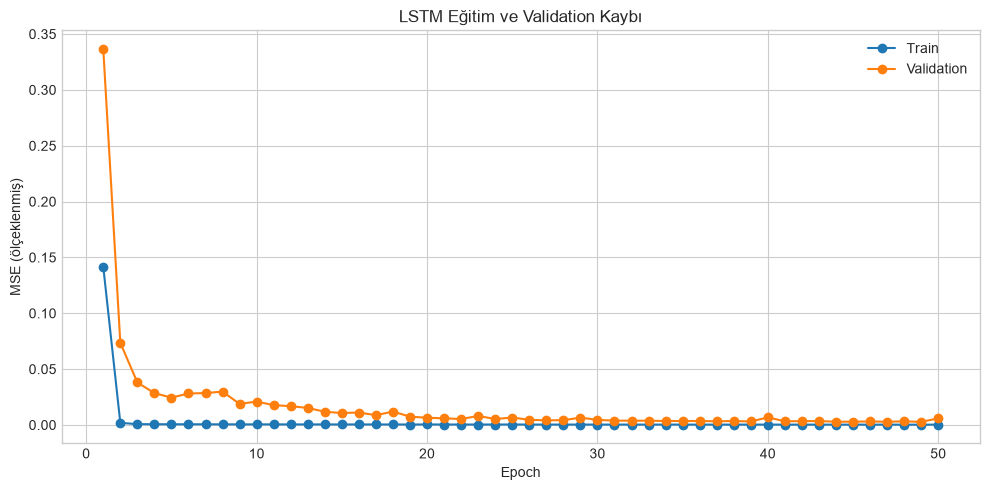

In [5]:
display(history_df)

fig, ax = plt.subplots(figsize=(10, 5))
history_df.plot(ax=ax, marker="o")
ax.set_title("LSTM Eğitim ve Validation Kaybı")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (ölçeklenmiş)")
ax.legend(["Train", "Validation"])
plt.tight_layout()
plt.show()

## Validation sonuçları

Ölçeklenmiş çıktılar dolar ölçeğine geri çevrilir. LSTM, her gün için son bilinen kapanışı tahmin kabul eden naive baseline ile aynı validation hedefleri üzerinde karşılaştırılır.

In [6]:
model.eval()
with torch.no_grad():
    predicted_scaled = model(prepared.X_validation.to(DEVICE)).cpu().numpy()

actual_scaled = prepared.y_validation.numpy()
naive_scaled = prepared.X_validation[:, -1, 0].numpy().reshape(-1, 1)

predicted_usd = prepared.scaler.inverse_transform(predicted_scaled).ravel()
actual_usd = prepared.scaler.inverse_transform(actual_scaled).ravel()
naive_usd = prepared.scaler.inverse_transform(naive_scaled).ravel()

def regression_metrics(actual, predicted):
    errors = predicted - actual
    mse = np.mean(errors**2)
    return {
        "MSE (USD²)": mse,
        "RMSE (USD)": np.sqrt(mse),
        "MAE (USD)": np.mean(np.abs(errors)),
    }

metrics_df = pd.DataFrame(
    {
        "LSTM": regression_metrics(actual_usd, predicted_usd),
        "Naive baseline": regression_metrics(actual_usd, naive_usd),
    }
).T
display(metrics_df)

,MSE (USD²),RMSE (USD),MAE (USD)
LSTM,47.0467,6.8591,5.4549
Naive baseline,24.8756,4.9875,3.7967


In [7]:
assert predicted_scaled.shape == actual_scaled.shape
assert len(predicted_usd) == len(prepared.validation_target_dates)
assert np.isfinite(predicted_usd).all()
assert prepared.validation_target_dates.max() < prepared.test_target_dates.min()

print(f"Validation hedefi: {len(actual_usd):,}")
print(
    "Validation tarihleri: "
    f"{prepared.validation_target_dates.min().date()} - "
    f"{prepared.validation_target_dates.max().date()}"
)
print("Test dönemine ait tahmin veya metrik hesaplanmadı.")

Validation hedefi: 623
Validation tarihleri: 2021-07-26 - 2024-01-16
Test dönemine ait tahmin veya metrik hesaplanmadı.


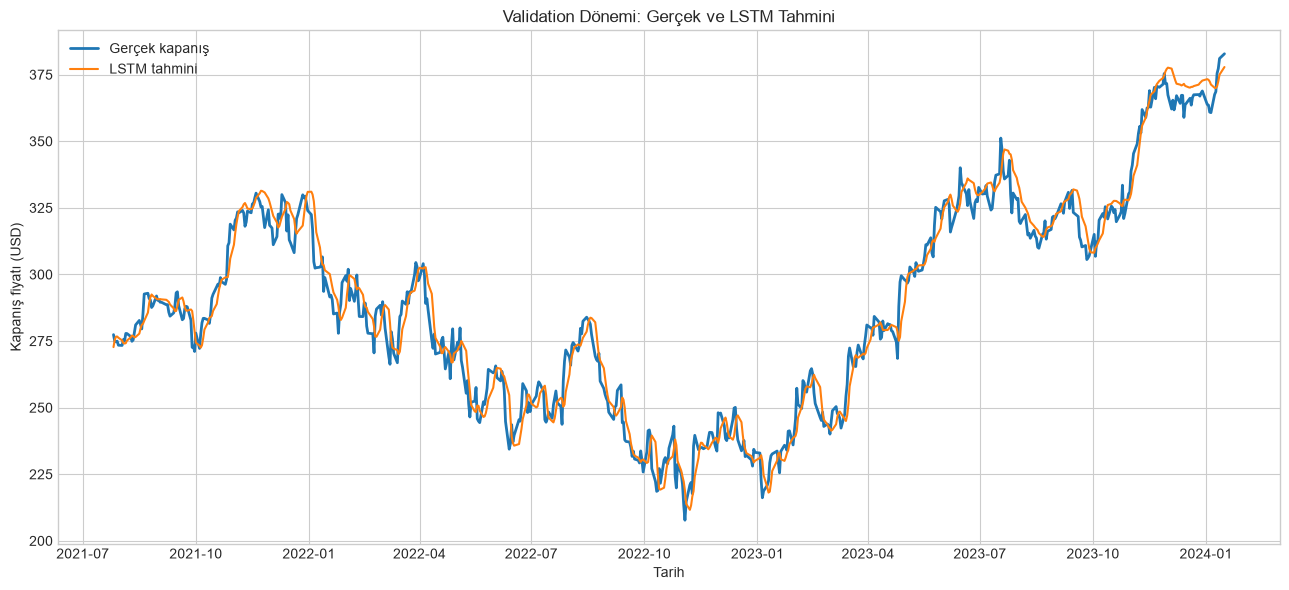

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    prepared.validation_target_dates,
    actual_usd,
    label="Gerçek kapanış",
    linewidth=2,
)
ax.plot(
    prepared.validation_target_dates,
    predicted_usd,
    label="LSTM tahmini",
    linewidth=1.5,
)
ax.set_title("Validation Dönemi: Gerçek ve LSTM Tahmini")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kapanış fiyatı (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Validation değerlendirmesi

Aşağıdaki çıktı, seçilen LSTM ağırlıkları ile naive baseline arasındaki RMSE farkını özetler. Pozitif fark LSTM'nin daha yüksek, negatif fark daha düşük hata ürettiğini gösterir.

In [9]:
lstm_rmse = metrics_df.loc["LSTM", "RMSE (USD)"]
naive_rmse = metrics_df.loc["Naive baseline", "RMSE (USD)"]
rmse_difference = lstm_rmse - naive_rmse

print(f"LSTM validation RMSE: {lstm_rmse:.4f} USD")
print(f"Naive validation RMSE: {naive_rmse:.4f} USD")
print(f"RMSE farkı (LSTM - naive): {rmse_difference:+.4f} USD")

LSTM validation RMSE: 6.8591 USD
Naive validation RMSE: 4.9875 USD
RMSE farkı (LSTM - naive): +1.8715 USD
